In [17]:
import matplotlib.pyplot as plt
import pandas as pd

In [18]:
def EstresPorGenero(datos):

  nivel_genero = datos.groupby(['stress_experience', 'gender']).size().unstack(fill_value=0)


  nivel_genero = nivel_genero.sort_index()

  # Graficar
  nivel_genero.plot(
      kind='bar',
      figsize=(10, 6),
      color=['skyblue', 'darkblue']
  )

  plt.title('Distribución del Estrés por Nivel y Género en la Universidad Internacional Daffodil en Bangladesh en el año 2025')
  plt.xlabel('Nivel de Estrés (1-5)')
  plt.ylabel('Cantidad de Personas')
  plt.xticks(rotation=0)
  plt.legend(['Hombre', 'Mujer'])
  plt.tight_layout()
  plt.figtext(0.5, -0.05, 'Fuente: Datos obtenidos de Mendeley Data; Mondol y Kabir (2025), "Stress Indicators Dataset for Mental Health Classification"',
              ha='center', fontsize=10)

  plt.show()

In [19]:
def Relacion_FaltasDeSueño_Sobrecarga(datos):

  faltas_genero = datos.groupby(['sleep_problems', 'gender']).size().unstack(fill_value=0)


  faltas_genero = faltas_genero.sort_index()
  line_data = datos.groupby('stress_experience')[['sleep_problems', 'academic_conflicts']].mean()

  # Graficar líneas
  plt.figure(figsize=(10,6))

  plt.plot(line_data.index, line_data['sleep_problems'], marker='o', label='Falta de sueño')
  plt.plot(line_data.index, line_data['academic_conflicts'], marker='o', label='Sobrecarga académica')

  plt.title('Comparación de Falta de Sueño y Sobrecarga Académica por Nivel de Estrés en la Universidad Internacional Daffodil en Bangladesh en el año 2025')
  plt.xlabel('Nivel de Estrés (1-5)')
  plt.ylabel('Promedio')
  plt.legend()
  plt.grid()
  plt.tight_layout()
  plt.figtext(0.5, -0.05, 'Fuente: Datos obtenidos de Mendeley Data; Mondol y Kabir (2025), "Stress Indicators Dataset for Mental Health Classification"',
              ha='center', fontsize=10)

  plt.show()

In [20]:
def Relacion_Fatiga_Concentracion(datos):
  # Calculate mean of restlessness and concentration_problems for each stress_experience level
  avg_data = datos.groupby('stress_experience')[['restlessness', 'concentration_problems']].mean()

  plt.figure(figsize=(10,6))
  plt.plot(avg_data.index, avg_data['restlessness'], marker='o', label='Inquietud', color='red')
  plt.plot(avg_data.index, avg_data['concentration_problems'], marker='o', label='Problemas de Concentración', color='green')

  plt.title('Comparación de Inquietud y Problemas de Concentración por Nivel de Estrés en la Universidad Internacional Daffodil en Bangladesh en el año 2025')
  plt.xlabel('Nivel de Estrés (1-5)')
  plt.ylabel('Promedio')
  plt.legend()
  plt.grid()
  plt.tight_layout()
  plt.figtext(0.5, -0.05, 'Fuente: Datos obtenidos de Mendeley Data; Mondol y Kabir (2025), "Stress Indicators Dataset for Mental Health Classification"',
            ha='center', fontsize=10)

  plt.show()

In [21]:
def Relacion_Rendimiento_BalanceVida(datos):
  # Calculate mean of low_academic_confidence and lack_relaxation_time for each stress_experience level
  avg_data = datos.groupby('stress_experience')[['low_academic_confidence', 'lack_relaxation_time']].mean()

  plt.figure(figsize=(10,6))
  plt.plot(avg_data.index, avg_data['low_academic_confidence'], marker='o', label='Baja Confianza Académica', color='purple')
  plt.plot(avg_data.index, avg_data['lack_relaxation_time'], marker='o', label='Falta de Tiempo de Relajación', color='darkblue')

  plt.title('Comparación de Baja Confianza Académica y Falta de Tiempo de Relajación por Nivel de Estrés en la Universidad Internacional Daffodil en Bangladesh en el año 2025')
  plt.xlabel('Nivel de Estrés (1-5)')
  plt.ylabel('Promedio')
  plt.legend()
  plt.grid()
  plt.tight_layout()
  plt.figtext(0.5, -0.05, 'Fuente: Datos obtenidos de Mendeley Data; Mondol y Kabir (2025), "Stress Indicators Dataset for Mental Health Classification"',
              ha='center', fontsize=10)

  plt.show()

In [22]:
datos = pd.read_csv('/content/Stress Indicators Dataset for Mental Health Classification.csv')

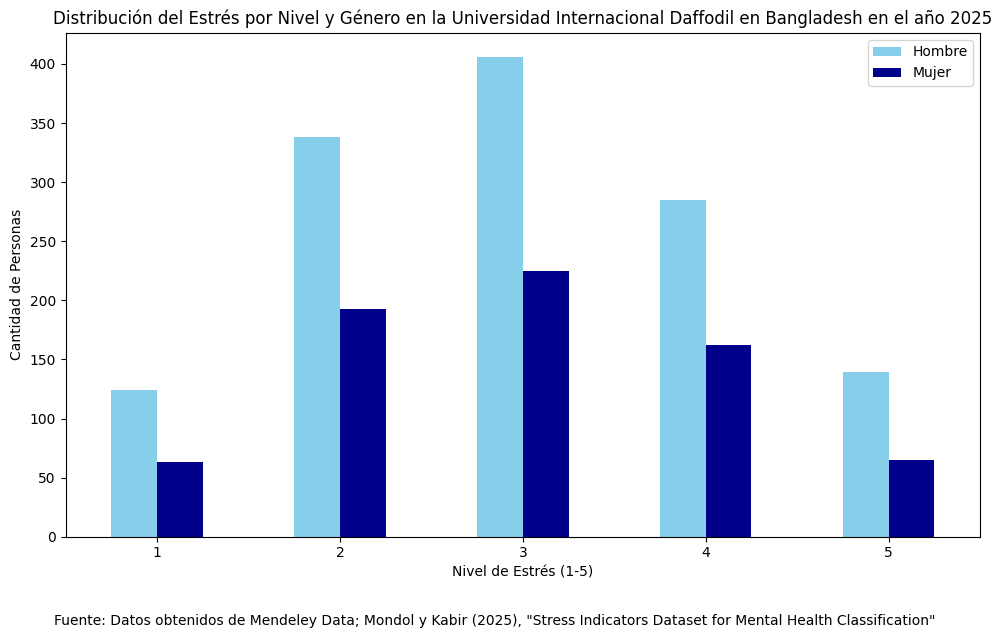

In [23]:
EstresPorGenero(datos)

In [55]:
def analisis_estres_por_edad(datos, umbral_grave=4):
    """
    Analiza la gravedad del estrés comparando diferentes grupos de edad.
    """
    df = datos.copy()

    # Crear grupos de edad
    def grupo_edad(edad):
        if edad < 18:
            return 'Adolescente (<18)'
        elif edad <= 25:
            return 'Adulto joven (19-25)'
        elif edad <= 35:
            return 'Adulto (26-35)'
        else:
            return 'Adulto (36+)'

    df['grupo_edad'] = df['age'].apply(grupo_edad)

    # Orden de grupos
    orden_grupos = ['Adolescente (<18)', 'Adulto joven (19-25)', 'Adulto (26-35)', 'Adulto (36+)']

    print("\n" + "="*80)
    print("                     ANÁLISIS DE GRAVEDAD DE ESTRÉS POR EDAD")
    print("="*80)

    # Encabezados
    print(f"{'Grupo de edad':<20} {'Personas':>8} {'% Angustia':>12} {'% Eustrés':>11} {'% Mixto':>9}")
    print("-"*80)

    # Diccionario para guardar porcentajes de angustia
    angustia_por_grupo = {}

    for grupo in orden_grupos:
        if grupo in df['grupo_edad'].values:
            subset = df[df['grupo_edad'] == grupo]
            total = len(subset)

            pct_angustia = (subset['stress_type'] == 0).sum() / total * 100
            pct_eustres = (subset['stress_type'] == 1).sum() / total * 100
            pct_mixto = (subset['stress_type'] == 2).sum() / total * 100

            # Guardar para el resumen
            angustia_por_grupo[grupo] = pct_angustia

            print(f"{grupo:<20} {total:>8} {pct_angustia:>11.1f}% {pct_eustres:>10.1f}% {pct_mixto:>8.1f}%")

    print("="*80)

    # Resumen ejecutivo
    print("\n" + "-"*80)
    print("RESUMEN EJECUTIVO (ENFOQUE EN ANGUSTIA - ESTRÉS NEGATIVO):")
    print("-"*80)

    # Encontrar grupo con mayor y menor angustia
    grupo_max_angustia = max(angustia_por_grupo, key=angustia_por_grupo.get)
    max_angustia = angustia_por_grupo[grupo_max_angustia]

    grupo_min_angustia = min(angustia_por_grupo, key=angustia_por_grupo.get)
    min_angustia = angustia_por_grupo[grupo_min_angustia]

    print(f"⚠️  Grupo con MAYOR porcentaje de ANGUSTIA (estrés negativo): {grupo_max_angustia}")
    print(f"   → {max_angustia:.1f}% de este grupo tiene estrés negativo que requiere intervención")

    print(f"\n✓ Grupo con MENOR porcentaje de ANGUSTIA: {grupo_min_angustia}")
    print(f"   → {min_angustia:.1f}% de este grupo tiene estrés negativo")

    # Diferencia
    diferencia = max_angustia - min_angustia
    print(f"\n📊 Diferencia entre grupos: {diferencia:.1f} puntos porcentuales")

    print("="*80 + "\n")

    return None

analisis_estres_por_edad(datos, umbral_grave=4)




                     ANÁLISIS DE GRAVEDAD DE ESTRÉS POR EDAD
Grupo de edad        Personas   % Angustia   % Eustrés   % Mixto
--------------------------------------------------------------------------------
Adolescente (<18)          88         3.4%       85.2%     11.4%
Adulto joven (19-25)     1862         3.5%       91.7%      4.8%
Adulto (26-35)             21         0.0%      100.0%      0.0%
Adulto (36+)               29         6.9%       82.8%     10.3%

--------------------------------------------------------------------------------
RESUMEN EJECUTIVO (ENFOQUE EN ANGUSTIA - ESTRÉS NEGATIVO):
--------------------------------------------------------------------------------
⚠️  Grupo con MAYOR porcentaje de ANGUSTIA (estrés negativo): Adulto (36+)
   → 6.9% de este grupo tiene estrés negativo que requiere intervención

✓ Grupo con MENOR porcentaje de ANGUSTIA: Adulto (26-35)
   → 0.0% de este grupo tiene estrés negativo

📊 Diferencia entre grupos: 6.9 puntos porcentuales




------------------------------------------------------------
        TOP 5 SÍNTOMAS GRAVES MÁS FRECUENTES (>= 4)
------------------------------------------------------------
 #   Síntoma                               Personas Porcentaje
------------------------------------------------------------
 1   Class Attendance                           917     45.9%
 2   Stress Experience                          651     32.6%
 3   Sleep Problems                             590     29.5%
 4   Irritability                               587     29.3%
 5   Academic Conflicts                         581     29.0%
------------------------------------------------------------

----------------------------------------
📊 Datos complementarios:
   • Total de personas evaluadas: 2000
   • Total de síntomas analizados: 23
   • Síntoma más frecuente: Class Attendance (917 personas)



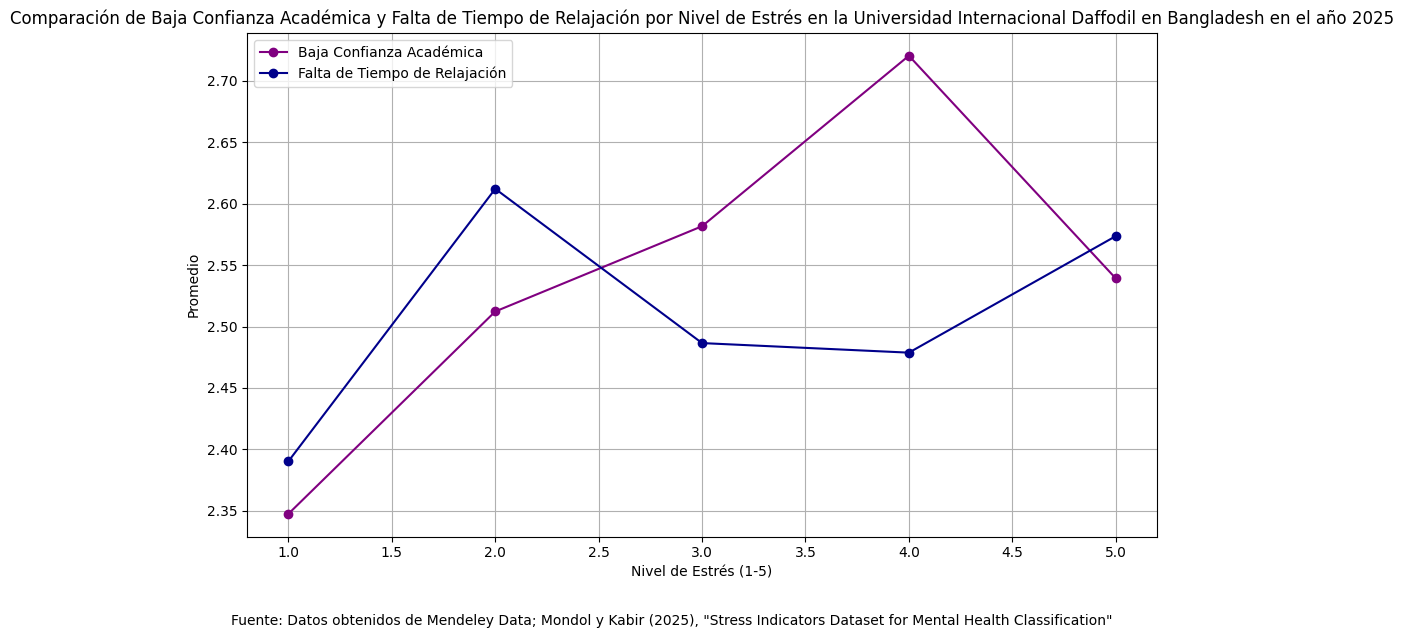

In [43]:
def top_sintomas_graves(df, umbral, top_n):
    # Excluir columnas no indicadoras
    exclude_cols = ['gender', 'age', 'stress_type']
    indicator_cols = [col for col in df.columns if col not in exclude_cols]

    # Calcular frecuencia de síntomas graves
    total_personas = len(df)
    frecuencias = {}

    for col in indicator_cols:
        frecuencias[col] = (df[col] >= umbral).sum()

    # Ordenar y tomar top_n
    top_sintomas = sorted(frecuencias.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # Crear tabla con print
    print("\n" + "-"*60)
    print(f"        TOP {top_n} SÍNTOMAS GRAVES MÁS FRECUENTES (>= {umbral})")
    print("-"*60)

    # Encabezados
    print(f"{'#':^4} {'Síntoma':<35} {'Personas':>10} {'Porcentaje':>9}")
    print("-"*60)

    # Filas
    for i, (sintoma, count) in enumerate(top_sintomas, 1):
        porcentaje = (count / total_personas) * 100
        nombre_limpio = sintoma.replace('_', ' ').title()
        print(f"{i:^4} {nombre_limpio:<35} {count:>10} {porcentaje:>8.1f}%")

    print("-"*60)

    # Estadísticas adicionales
    print("\n" + "-"*40)
    print(f"📊 Datos complementarios:")
    print(f"   • Total de personas evaluadas: {total_personas}")
    print(f"   • Total de síntomas analizados: {len(indicator_cols)}")
    print(f"   • Síntoma más frecuente: {top_sintomas[0][0].replace('_', ' ').title()} ({top_sintomas[0][1]} personas)")

    # Mostrar si hay síntomas con 0 casos
    sintomas_cero = [s for s, c in frecuencias.items() if c == 0]
    if sintomas_cero:
        print(f"   • Síntomas sin casos graves: {len(sintomas_cero)}")

    print("="*60 + "\n")

    return top_sintomas

# Ejecutar
top_sintomas_graves(datos, umbral=4, top_n=5)



